<a href="https://colab.research.google.com/github/svyatoslavna/ml_hw/blob/main/clustering_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

# Часть 1. K-Means

In [5]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-04 18:45:50--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.04s   

2026-05-04 18:45:51 (1.86 MB/s) - ‘wineqr.csv’ saved [84143/84143]



1. Загрузка и предобработка

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [6]:
df = pd.read_csv('wineqr.csv')

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
X = df.drop(columns=['quality'])

In [9]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. K-Means с выбором K (локоть + силуэт)

In [10]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


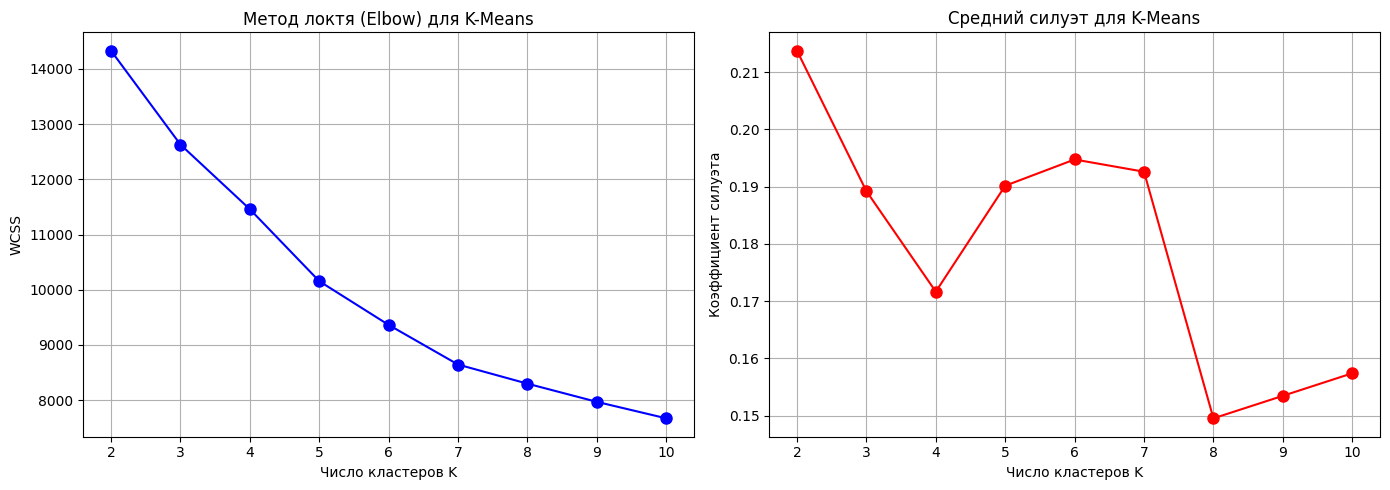

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [13]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

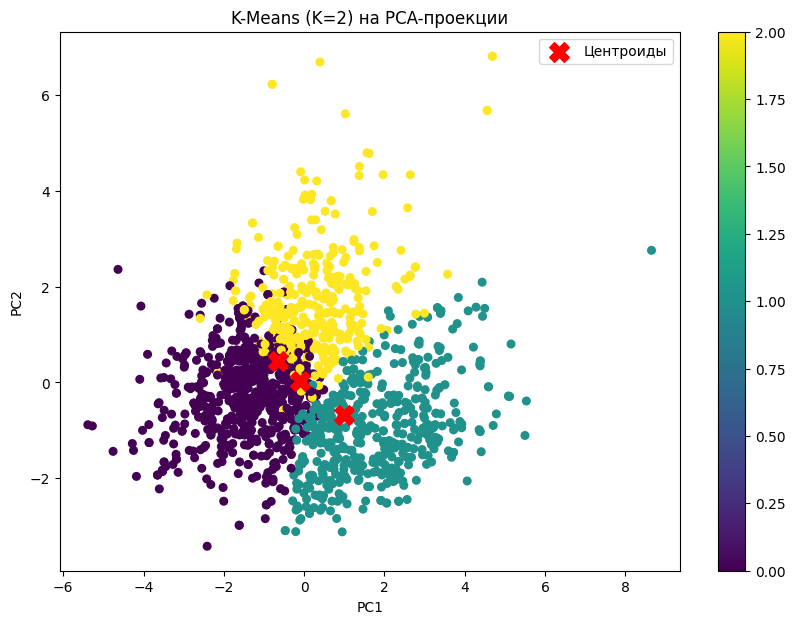

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

# Часть 2. DBSCAN

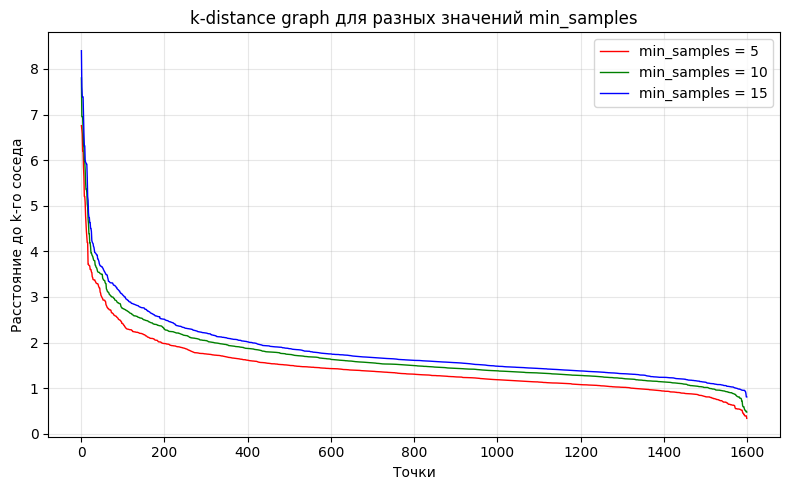

In [15]:
plt.figure(figsize=(8, 5))


colors = ['r', 'g', 'b']

for i, k in enumerate([5, 10, 15]):

    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    k_dist = distances[:, -1]
    k_dist_sorted = np.sort(k_dist)[::-1] # чтобы получилась форма локтя (или неважно..?)


    plt.plot(range(1, len(k_dist_sorted) + 1), k_dist_sorted,
             color=colors[i], linewidth=1, label=f'min_samples = {k}')

plt.xlabel('Точки')
plt.ylabel('Расстояние до k-го соседа')
plt.title('k-distance graph для разных значений min_samples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [104]:
min_samples = [5, 10, 15]
silhouette_scores = []


# в задании было написано до 1.1, я решила воспринять это как до 1.1 ВКЛЮЧИТЕЛЬНО,
# т.к. если не включать 1.1, то получаются совсем грустные результаты:
# по условию с n_clusters_ и noise_rate проходила только одна комбинация

for eps in np.arange(0.3, 1.2, 0.1):
    for min_s in min_samples:
        db = DBSCAN(eps=eps, min_samples=min_s).fit(X_scaled)
        labels = db.labels_

        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)
        noise_rate = n_noise_ * 100 / len(X_scaled)

        if n_clusters_ >= 2 and noise_rate <= 80:

            sil = silhouette_score(X_scaled, labels)
            print(f"Eps={eps:.1f}: min_samples={min_s}, silhouette={sil:.3f}")
            print(f"Кластеров: {n_clusters_}\n")
        else:
            continue


    # макс. силуэт получился в последнем случае -
    # Eps=1.1: min_samples=10, silhouette=-0.224, Кластеров: 7

Eps=1.0: min_samples=5, silhouette=-0.318
Кластеров: 24

Eps=1.1: min_samples=5, silhouette=-0.320
Кластеров: 18

Eps=1.1: min_samples=10, silhouette=-0.224
Кластеров: 7



In [34]:
db_final = DBSCAN(min_samples=10, eps=1.1)
db_labels = db_final.fit_predict(X_scaled)

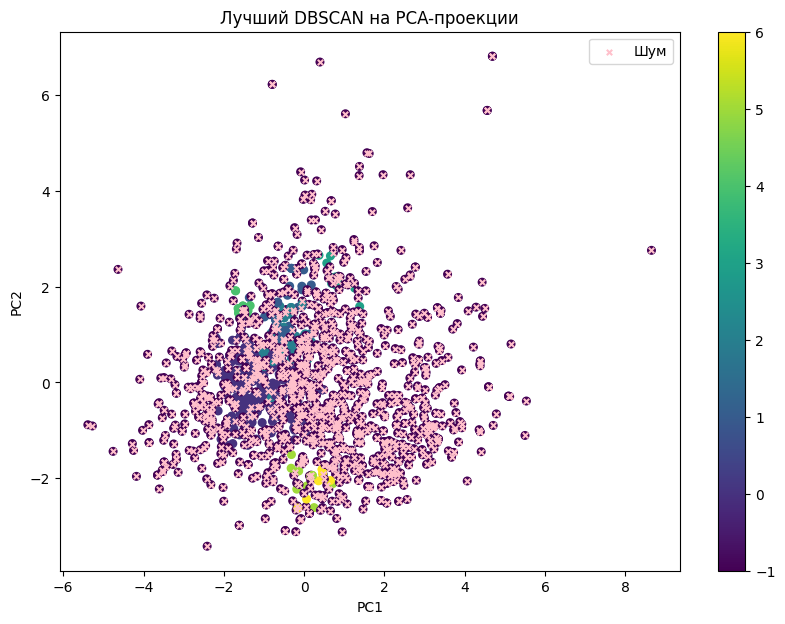

In [61]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=db_labels, cmap='viridis', s=30
    )

plt.scatter(
    X_pca[db_labels == -1, 0], X_pca[db_labels == -1, 1],
    c='pink', s=15, marker='x', label='Шум'
    )

plt.title(f'Лучший DBSCAN на PCA-проекции')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
plt.show()

**Ответьте на вопросы (письменно):**

1. Почему для DBSCAN критически важно масштабировать данные?


> Потому что DBSCAN считает расстояния между точками в евклидовом пространстве и если признаки имеют разные масштабы (сравним: возраст от 18 до 99 vs. зарплата от 40 тыс. до 400 тыс.) большие числовые значения будут доминировать при вычислении расстояний, и тогда близкие точки будут казаться далекими, а кластеры не будут найдены.

2. Что будет при слишком маленьком eps? Слишком большом?


> Более маленькие значения приводят к большему количеству кластеров. Большое значение eps - к меньшему количеству кластеров. И то, и другое может помешать решению задачи кластеризации, т.к. в первом случае есть риск слишком сильно поделить выборку на бессмысленные группы (как в Вашем, Виктория Игоревна, примере про фанфики), во втором - не увидеть кластеры вообще, объединить все в слишком большие и негомогенные группы.


3. Что означают точки с меткой -1?


> Шум, выбросы.
> **labels** - "Noisy samples are given the label -1".


4. Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?


> DBSCAN может находить кластеры произвольной формы, в то время как кластеры в K-Means предполагают выпуклую форму.



# Часть 3. OPTICS (домашнее задание)

In [96]:
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
optics_labels = optics.fit_predict(X_scaled)

In [95]:
n_clusters_ = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise_ = list(optics_labels).count(-1)

if n_clusters_ >= 2:
    sil = silhouette_score(X_scaled, optics_labels)
    print(f"Silhouette={sil:.3f}")

else:
    print('Подсчитать Silhouette нельзя, если кластеров меньше 2.\n')

print(f"Кластеров: {n_clusters_}")
print(f"Количество шумовых точек: {n_noise_}")

Подсчитать Silhouette нельзя, если кластеров меньше 2.

Кластеров: 1
Количество шумовых точек: 0


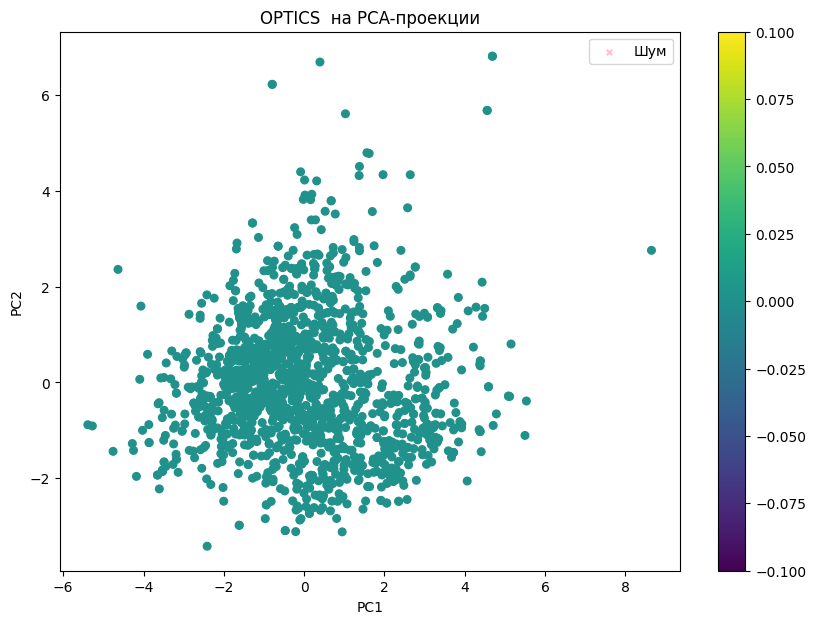

In [83]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=optics_labels, cmap='viridis', s=30
    )

# шума не будет, но для наглядости оставила:
plt.scatter(
    X_pca[optics_labels == -1, 0], X_pca[optics_labels == -1, 1],
    c='pink', s=15, marker='x', label='Шум'
    )

plt.title(f'OPTICS  на PCA-проекции')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
plt.show()

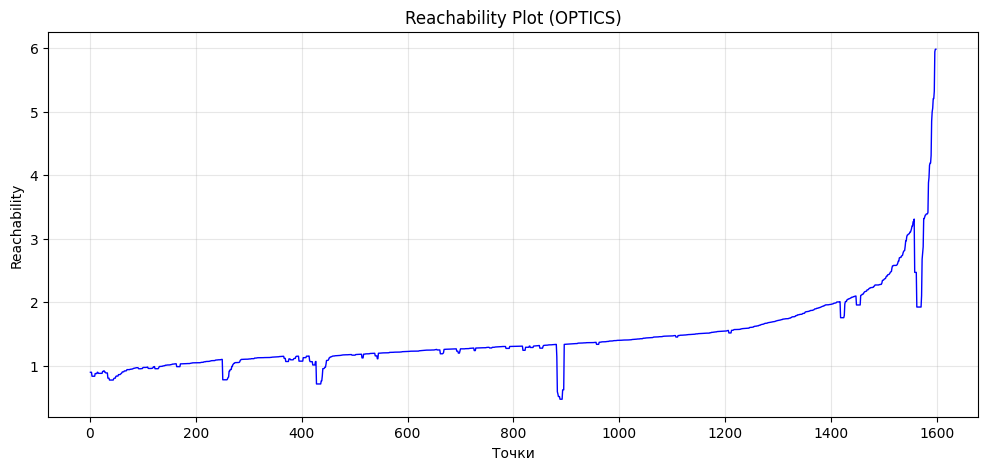

In [98]:
plt.figure(figsize=(12, 5))

plt.plot(optics.reachability_[optics.ordering_], 'b', linewidth=1)
plt.title('Reachability Plot (OPTICS)')
plt.xlabel('Точки')
plt.ylabel('Reachability')
plt.grid(True, alpha=0.3)

plt.show()

# кластер всего один :( но при этом сильные перепады есть,
# значит, проблема не в xi=0.05...

**Ответьте на вопросы (письменно, развёрнуто):**

1. Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия.**


> Во-первых, OPTICS в отличие от DBSCAN не требует параметра eps, т.к.он способен выделять кластеры разной плотности. Во-вторых, OPTICS видит иерархию кластеров - находит вложенные друг в друга кластеры.


2. Что такое параметр xi (кси) и как он влияет на выделение кластеров?


> Xi определяет, насколько резким должен быть перепад на графике сходимости, чтобы отделить один кластер от другого. При маленьком xi даже небольшие перепады становятся границами между кластерами, в результате мы имеем больше кластеров. При большом xi перепад тоже должен быть большим, чтобы провести границу, отсюда - меньше кластеров.

3. В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.


> OPTICS лучше справляется на данных, в которых есть кластеры разной плотности. Например, в случае, если первый кластер более разреженный, чем другой, то один из них просто окажется незамеченным, т.к. фиксировано одно конкретное значение eps. Потенциальный кластер либо будет засчитан за отдельные шумовые точки, либо склеется с другим кластером.


4. Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).
Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?



> Если рассматривать DBSCAN и OPTICS, то DBSCAN справляется быстрее (а K-Means ещё быстрее, *см. код ниже*). Главный показатель.  Лучше всего разделил данные K-Means. **Главный показатель - Silhouette:** 1) **K-Means: 0.214;** 2) DBSCAN: -0.224; 3) OPTICS: подсчитать нельзя. OPTICS не выделил кластеры совсем, а DBSCAN сделал это неоптимально, что можно определить по очень низкому Silhouette и большому проценту шумовых точек (77.2%, *см. код ниже*). Возможно, форма кластеров по K-Means неидельна, но группировка выглядит наиболее осмысленной. В данном случае более простой алгоритм подошёл лучше всего. Тем не менее, важно уточнить, что параметры алгоритмов не всегда подбирались достаточно тщательно — при более детальной настройке результаты могли бы измениться.





In [103]:
# K-Means
start = time.time()
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
kmeans_time = time.time() - start

# DBSCAN
start = time.time()
dbscan = DBSCAN(eps=1.1, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_time = time.time() - start

# OPTICS
start = time.time()
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
optics_labels = optics.fit_predict(X_scaled)
optics_time = time.time() - start

print(f"K-Means: {kmeans_time:.4f} сек")
print(f"DBSCAN: {dbscan_time:.4f} сек")
print(f"OPTICS: {optics_time:.4f} сек")

K-Means: 0.0211 сек
DBSCAN: 0.0409 сек
OPTICS: 1.1250 сек


In [110]:
dbscan = DBSCAN(eps=1.1, min_samples=10)
best_labels = db_best.fit_predict(X_scaled)

noise_result = (best_labels == -1).sum() / len(best_labels) * 100
print(f"Доля шума для DBSCAN: {noise_result:.1f}%")

Доля шума для DBSCAN: 77.2%
